# **Desafio Final**

## **🛠️ Preparación de los Datos**

### **Extracción del Archivo Tratado**

In [148]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [149]:
datos = pd.read_csv('telecomx_latam_limpio.csv')
datos.head()

,id_cliente,cancelacion,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,...,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargos_mensuales,cargos_totales,cargos_diarios,rango_costo
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.156710,"(58.45, 78.55]"
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.969313,"(58.45, 78.55]"
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.429586,"(58.45, 78.55]"
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.221914,"(78.55, 98.65]"
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.758353,"(78.55, 98.65]"


### **Eliminación de Columnas Irrelevantes**

In [150]:
#Eliminando columnas que no aportan al modelo

datos_limpios = datos.drop(columns=["id_cliente", 'rango_costo'])

Se eliminaron estas columnas porque no aportaban información relevante para el entrenamiento de los modelos.

In [151]:
datos_limpios.columns

Index(['cancelacion', 'genero', 'adulto_mayor', 'tiene_pareja',
       'tiene_dependientes', 'antiguedad_meses', 'servicio_telefonico',
       'lineas_multiples', 'servicio_internet', 'seguridad_online',
       'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'facturacion_digital', 'metodo_pago', 'cargos_mensuales',
       'cargos_totales', 'cargos_diarios'],
      dtype='object')

In [152]:
columnas = ['lineas_multiples', 'seguridad_online',
       'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas']

In [153]:
mapping = {'yes': 1, 'no': 0}
datos_limpios[columnas] = datos_limpios[columnas].apply(
    lambda col: col.astype(str).str.strip().str.lower().map(mapping).fillna(0).astype(int)
)

In [154]:
#Eliminando columnas redundantes
datos_limpios = datos_limpios.drop(columns=["cargos_diarios"])

In [155]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cancelacion             7032 non-null   int64  
 1   genero                  7032 non-null   object 
 2   adulto_mayor            7032 non-null   int64  
 3   tiene_pareja            7032 non-null   int64  
 4   tiene_dependientes      7032 non-null   int64  
 5   antiguedad_meses        7032 non-null   int64  
 6   servicio_telefonico     7032 non-null   int64  
 7   lineas_multiples        7032 non-null   int64  
 8   servicio_internet       7032 non-null   object 
 9   seguridad_online        7032 non-null   int64  
 10  respaldo_online         7032 non-null   int64  
 11  proteccion_dispositivo  7032 non-null   int64  
 12  soporte_tecnico         7032 non-null   int64  
 13  streaming_tv            7032 non-null   int64  
 14  streaming_peliculas     7032 non-null   


En esta etapa del preprocesamiento, mi objetivo fue **quitar variables que no aportaban valor real al modelo** y dejar un conjunto de datos más limpio para entrenar.

Primero, eliminé las columnas `id_cliente` y `rango_costo`:

- `id_cliente` no contiene información predictiva, porque es solo un identificador único por registro.
- `rango_costo` la descarté porque no aportaba una señal relevante para el objetivo en comparación con otras variables más útiles del dataset.

Segundo Eliminé también `cargos_diarios` porque la consideré **redundante** con otras variables de facturación (por ejemplo, las de cobro mensual), por lo que mantenerla podía introducir información repetida.

Tercero modifique las columnas con datos datos de `yes` y  `no` por 1 y 0 para facilitar su futuro uso en los modelos(Las celdas de servicio no contratado por se consideron redundantes y se coloco como 0 al igual que no)


Finalmente, utilicé `datos_limpios.info()` para verificar que las columnas se eliminaron correctamente y confirmar la estructura final antes de pasar al proceso de encoding.

Con esto, dejé el dataset más consistente, reduje ruido y preparé mejor los datos para el entrenamiento de los modelos.

### **Encoding**

In [156]:
X = datos_limpios.drop(columns=['cancelacion'])
y = datos_limpios['cancelacion']

In [157]:
X.head()

,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargos_mensuales,cargos_totales
0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [158]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   genero                  7032 non-null   object 
 1   adulto_mayor            7032 non-null   int64  
 2   tiene_pareja            7032 non-null   int64  
 3   tiene_dependientes      7032 non-null   int64  
 4   antiguedad_meses        7032 non-null   int64  
 5   servicio_telefonico     7032 non-null   int64  
 6   lineas_multiples        7032 non-null   int64  
 7   servicio_internet       7032 non-null   object 
 8   seguridad_online        7032 non-null   int64  
 9   respaldo_online         7032 non-null   int64  
 10  proteccion_dispositivo  7032 non-null   int64  
 11  soporte_tecnico         7032 non-null   int64  
 12  streaming_tv            7032 non-null   int64  
 13  streaming_peliculas     7032 non-null   int64  
 14  tipo_contrato           7032 non-null   

In [159]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['genero', 'servicio_internet', 'tipo_contrato', 'metodo_pago'], dtype='object')


In [160]:
X[categorical_cols].nunique()

genero               2
servicio_internet    3
tipo_contrato        3
metodo_pago          4
dtype: int64

In [161]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore', drop='if_binary')

In [162]:

tranformer = make_column_transformer(
    (encoder, categorical_cols),
    remainder='passthrough'
)

In [163]:
X = tranformer.fit_transform(X)


In [164]:
X = pd.DataFrame(data=X, columns=tranformer.get_feature_names_out(), index=datos.index)
X.head()

,onehotencoder__genero_Male,onehotencoder__servicio_internet_DSL,onehotencoder__servicio_internet_Fiber optic,onehotencoder__servicio_internet_No,onehotencoder__tipo_contrato_Month-to-month,onehotencoder__tipo_contrato_One year,onehotencoder__tipo_contrato_Two year,onehotencoder__metodo_pago_Bank transfer (automatic),onehotencoder__metodo_pago_Credit card (automatic),onehotencoder__metodo_pago_Electronic check,...,remainder__lineas_multiples,remainder__seguridad_online,remainder__respaldo_online,remainder__proteccion_dispositivo,remainder__soporte_tecnico,remainder__streaming_tv,remainder__streaming_peliculas,remainder__facturacion_digital,remainder__cargos_mensuales,remainder__cargos_totales
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40



En esta parte preparé las variables para que los modelos pudieran trabajar correctamente con los datos.

Primero, separé las variables en:

- `X`: todas las columnas de entrada.
- `y`: la columna objetivo (`cancelacion`).

Después, revisé la estructura de `X` con `head()` e `info()` para verificar tipos de datos y confirmar cuáles columnas seguían siendo categóricas.

Luego identifiqué las columnas tipo `object` con `select_dtypes`, porque esas no se pueden usar directamente en la mayoría de algoritmos de machine learning.

Para transformarlas, utilicé `OneHotEncoder` con esta configuración:

- `sparse_output=False`: para obtener una salida en formato denso y más fácil de inspeccionar.
- `handle_unknown='ignore'`: para evitar errores si en nuevos datos aparece una categoría no vista en entrenamiento.
- `drop='if_binary'`: para eliminar una de las dos categorías en variables binarias y reducir redundancia.

Finalmente, construí un `ColumnTransformer` para aplicar el encoder solo a las columnas categóricas y dejar el resto sin cambios (`remainder='passthrough'`). Con `fit_transform`, obtuve una matriz numérica lista para entrenar modelos.

Con este proceso convertí las variables categóricas en una representación adecuada, evité errores por tipos de datos y dejé el dataset preparado para modelado.

### **Verificación de la Proporción de Cancelación (Churn)**

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt

In [166]:
datos_limpios.cancelacion.value_counts(normalize=True).round(4) * 100

cancelacion
0    73.42
1    26.58
Name: proportion, dtype: float64

Text(0, 0.5, 'Porcentaje')

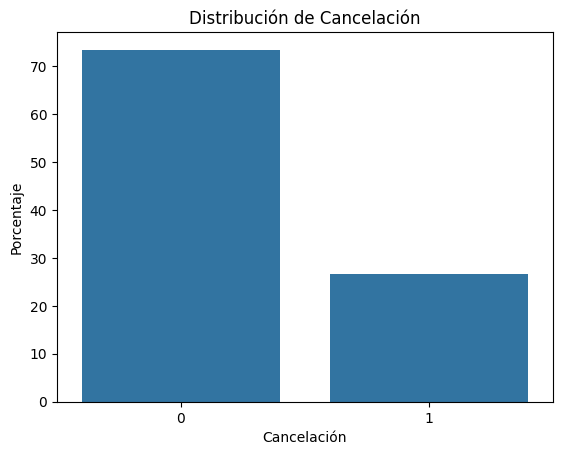

In [167]:
ax = sns.countplot(x='cancelacion', data= datos_limpios, stat='percent')
ax.set_title('Distribución de Cancelación')
ax.set_xlabel('Cancelación')
ax.set_ylabel('Porcentaje')

### **Normalización o Estandarización**

In [168]:
from sklearn.preprocessing import  MinMaxScaler
from statsmodels.api import add_constant

In [169]:
normalizador = MinMaxScaler()
X_normalizado = normalizador.fit_transform(X)

In [170]:
X_normalizado = pd.DataFrame(X_normalizado, columns=X.columns, index=X.index)
X_normalizado = add_constant(X_normalizado)
X_normalizado.head()

,const,onehotencoder__genero_Male,onehotencoder__servicio_internet_DSL,onehotencoder__servicio_internet_Fiber optic,onehotencoder__servicio_internet_No,onehotencoder__tipo_contrato_Month-to-month,onehotencoder__tipo_contrato_One year,onehotencoder__tipo_contrato_Two year,onehotencoder__metodo_pago_Bank transfer (automatic),onehotencoder__metodo_pago_Credit card (automatic),...,remainder__lineas_multiples,remainder__seguridad_online,remainder__respaldo_online,remainder__proteccion_dispositivo,remainder__soporte_tecnico,remainder__streaming_tv,remainder__streaming_peliculas,remainder__facturacion_digital,remainder__cargos_mensuales,remainder__cargos_totales
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.471144,0.066294
1,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.414428,0.060420
2,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.553731,0.030239
3,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.793532,0.140670
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.653234,0.028687


Se aplicó normalización con `MinMaxScaler` para escalar todas las variables al rango [0, 1]. Si bien RandomForest no es sensible a la escala de los datos, KNN sí lo es, ya que basa sus predicciones en distancias entre puntos: variables con rangos más amplios dominarían el cálculo sin una normalización previa. Por ello, se optó por usar datos normalizados en ambos modelos para mantener consistencia.

Adicionalmente, se añadió una **constante** al conjunto `X` mediante `add_constant`, lo que incorpora una columna de unos que actúa como término independiente. Esto es útil para modelos lineales que requieren un intercepto, y no afecta negativamente a los modelos basados en árboles o distancias.

## **🎯 Correlación y Selección de Variables**


### **Análisis de Correlación**

In [171]:
import numpy as np

In [172]:
datos_transformados = pd.DataFrame(data=X_normalizado, columns=tranformer.get_feature_names_out(), index=datos.index)
datos_transformados['cancelacion'] = y

In [173]:
corr_1 = datos_limpios.corr(numeric_only=True)

In [174]:
corr_transformados_cancelacion = datos_transformados.corr()['cancelacion'].sort_values(ascending=False)

Text(0.5, 1.0, 'Matriz de Correlación - Datos Originales')

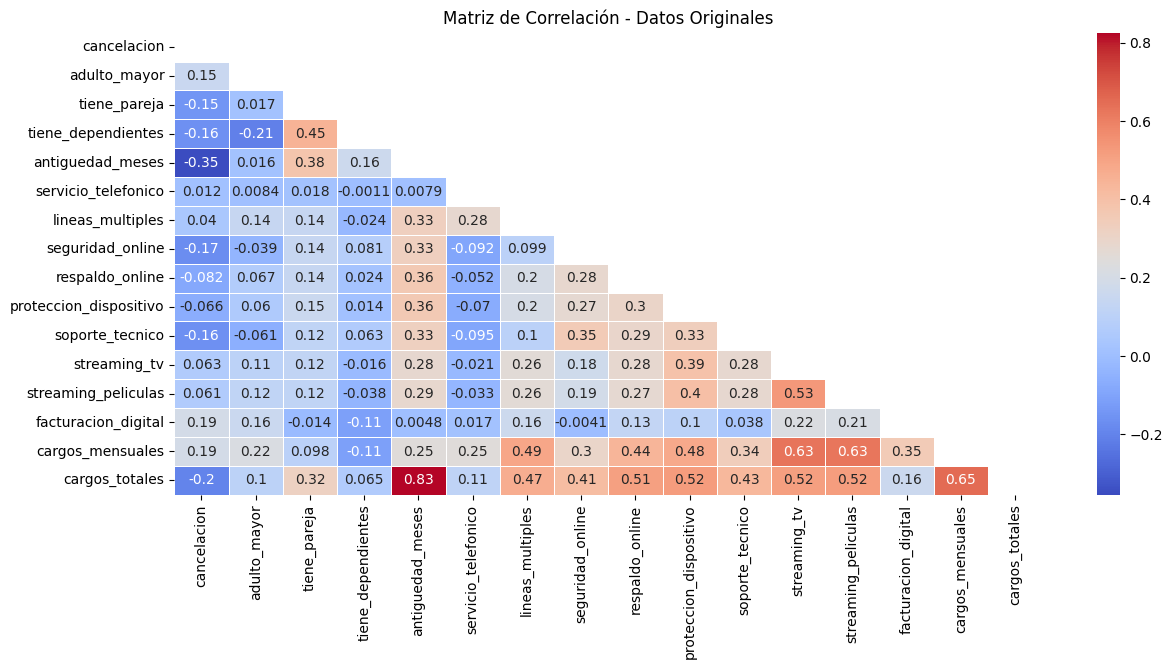

In [175]:
plt.figure(figsize=(14, 6))
mask = np.triu(np.ones_like(corr_1, dtype=bool))
sns.heatmap(corr_1, annot=True, cmap='coolwarm', linewidths=0.5, mask=mask)
plt.title('Matriz de Correlación - Datos Originales')

Text(0.5, 1.0, 'Matriz de Correlación - Datos Transformados')

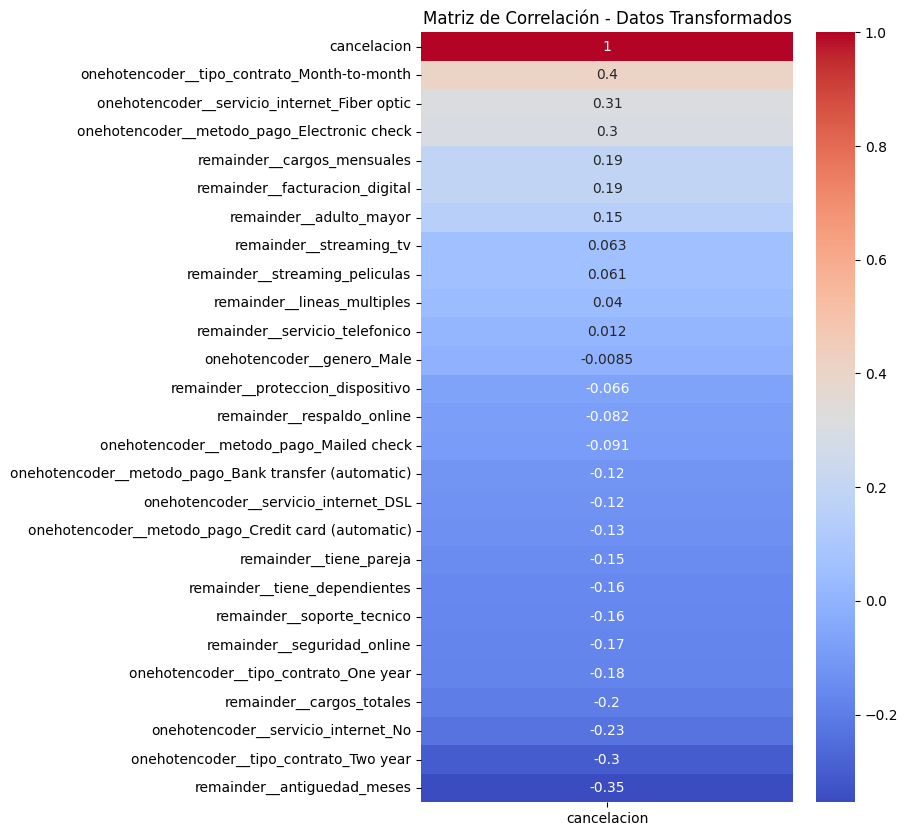

In [176]:
plt.figure(figsize=(6, 10))
sns.heatmap(corr_transformados_cancelacion.to_frame(), annot=True, cmap='coolwarm')

plt.title('Matriz de Correlación - Datos Transformados')


A partir de los mapas de correlación obtenidos, se pueden extraer las siguientes observaciones clave:

- **Tipo de contrato mes a mes** (`tipo_contrato_Month-to-month`): es la variable con mayor correlación positiva respecto a la cancelación. Los clientes bajo esta modalidad tienen una probabilidad notablemente más alta de abandonar el servicio, lo que sugiere que la falta de compromiso contractual es uno de los principales impulsores del churn.

- **Antigüedad del cliente** (`antiguedad_meses`): presenta una correlación negativa con la cancelación, lo que indica que a mayor tiempo que un cliente lleva con el servicio, menor es la probabilidad de que decida cancelar. Esto es coherente con la idea de que los clientes más antiguos desarrollan mayor fidelidad y están más integrados al servicio.

- **Tipo de contrato de dos años** (`tipo_contrato_Two year`): muestra correlación negativa con la cancelación, reforzando que los contratos de mayor duración actúan como factor de retención.

- **Servicios adicionales** como `seguridad_online` y `soporte_tecnico` también presentan correlación negativa con la cancelación, lo que indica que los clientes que cuentan con estos servicios tienden a permanecer más tiempo.

En resumen, los datos apuntan a que **el tipo de contrato y la antigüedad del cliente** son las variables con mayor poder explicativo sobre el churn, siendo los clientes con contratos mensuales y poca antigüedad el segmento de mayor riesgo.

### **Análisis Dirigido**

In [177]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cancelacion             7032 non-null   int64  
 1   genero                  7032 non-null   object 
 2   adulto_mayor            7032 non-null   int64  
 3   tiene_pareja            7032 non-null   int64  
 4   tiene_dependientes      7032 non-null   int64  
 5   antiguedad_meses        7032 non-null   int64  
 6   servicio_telefonico     7032 non-null   int64  
 7   lineas_multiples        7032 non-null   int64  
 8   servicio_internet       7032 non-null   object 
 9   seguridad_online        7032 non-null   int64  
 10  respaldo_online         7032 non-null   int64  
 11  proteccion_dispositivo  7032 non-null   int64  
 12  soporte_tecnico         7032 non-null   int64  
 13  streaming_tv            7032 non-null   int64  
 14  streaming_peliculas     7032 non-null   

Text(0.5, 0, 'Cancelación')

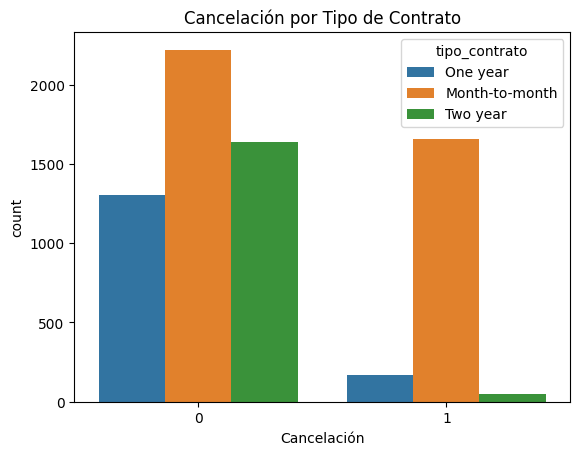

In [178]:
sns.countplot(data=datos_limpios, x='cancelacion', hue='tipo_contrato')
plt.title('Cancelación por Tipo de Contrato')
plt.xlabel('Cancelación')

Text(0.5, 0, 'Cancelación')

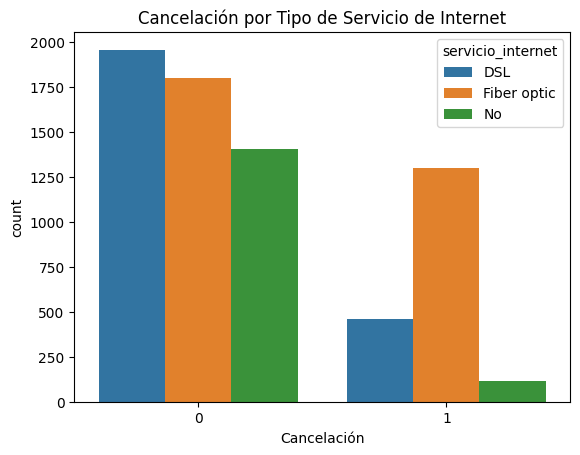

In [179]:
sns.countplot(data=datos_limpios, x='cancelacion', hue='servicio_internet')
plt.title('Cancelación por Tipo de Servicio de Internet')
plt.xlabel('Cancelación')

Text(0.5, 1.0, 'Cancelación por Seguridad Online')

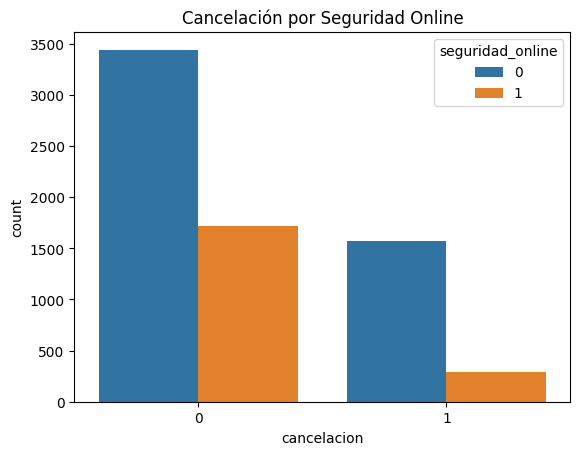

In [180]:
sns.countplot(data=datos_limpios, x='cancelacion', hue='seguridad_online')
plt.title('Cancelación por Seguridad Online')

Text(0.5, 0, 'Cancelación')

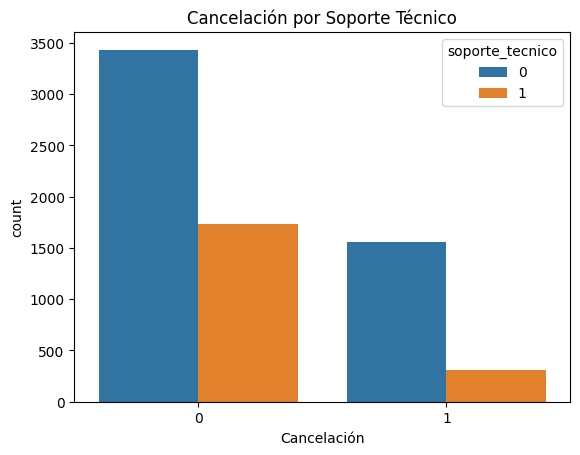

In [181]:
sns.countplot(data=datos_limpios, x='cancelacion', hue='soporte_tecnico')
plt.title('Cancelación por Soporte Técnico')
plt.xlabel('Cancelación')

Text(0.5, 0, 'Cancelación')

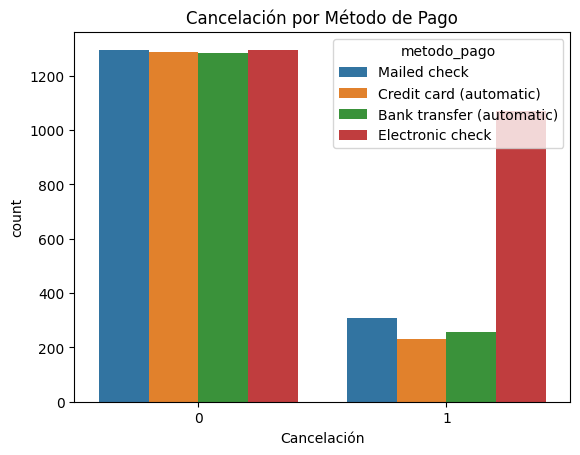

In [182]:
sns.countplot(data=datos_limpios, x='cancelacion', hue='metodo_pago')
plt.title('Cancelación por Método de Pago')
plt.xlabel('Cancelación')

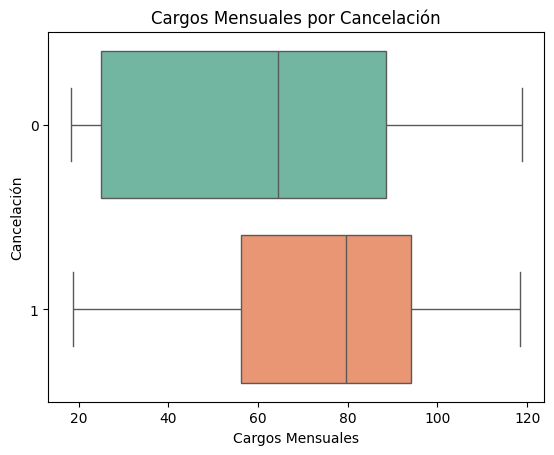

In [183]:
sns.boxplot(data=datos_limpios, x='cargos_mensuales', y='cancelacion', orient='h', 
            palette='Set2', legend=False)
plt.title('Cargos Mensuales por Cancelación')
plt.xlabel('Cargos Mensuales')
plt.ylabel('Cancelación')
plt.show()

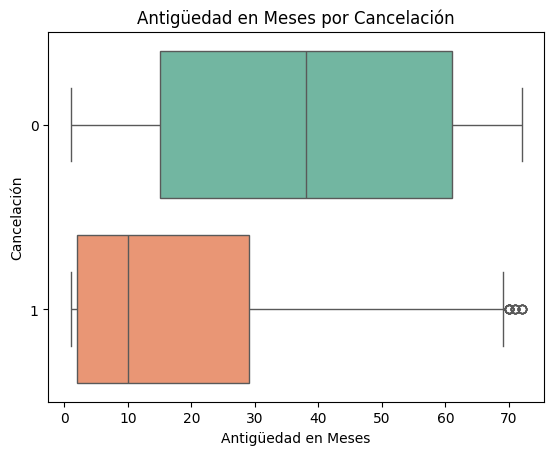

In [184]:
sns.boxplot(data=datos_limpios, x='antiguedad_meses', y='cancelacion', orient='h', 
            palette='Set2', legend=False)
plt.title('Antigüedad en Meses por Cancelación')
plt.xlabel('Antigüedad en Meses')
plt.ylabel('Cancelación')
plt.show()

### **Interpretación rápida de los gráficos (Análisis Dirigido)**

En esta sección, estas fueron mis conclusiones rápidas para cada gráfico:

1. **Cancelación por Tipo de Contrato**
   Observé que la cancelación se concentra más en contratos de menor compromiso (por ejemplo, mes a mes), mientras que en contratos más largos la cancelación tiende a bajar.

2. **Cancelación por Tipo de Servicio de Internet**
   Noté diferencias en la tasa de cancelación según el servicio de internet, lo que sugiere que el tipo/calidad percibida del servicio influye en la permanencia.

3. **Cancelación por Seguridad Online**
   Se aprecia que quienes no cuentan con seguridad online presentan mayor cancelación; tener este servicio parece asociarse con más retención.

4. **Cancelación por Soporte Técnico**
   Vi un patrón similar al anterior: la ausencia de soporte técnico se relaciona con mayor cancelación, posiblemente por menor satisfacción ante problemas.

5. **Cancelación por Método de Pago**
   El método de pago muestra diferencias claras en cancelación; algunos métodos concentran más bajas, lo que puede reflejar perfil de cliente o fricción en pagos.

6. **Boxplot: Cargos Mensuales por Cancelación**
   La distribución sugiere que los clientes que cancelan tienden a tener cargos mensuales más altos, por lo que el precio mensual aparece como factor relevante.

7. **Boxplot: Antigüedad en Meses por Cancelación**
   Se observa que quienes cancelan suelen tener menor antigüedad; a mayor tiempo con la empresa, menor probabilidad de cancelación.

En conjunto, estos gráficos me ayudaron a identificar variables clave para explicar la cancelación: **tipo de contrato, servicios de soporte/seguridad, método de pago, cargos mensuales y antigüedad**.

## **🤖 Modelado Predictivo**

### **Separación de Datos**

In [185]:
from sklearn.model_selection import train_test_split

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X_normalizado, y, test_size=0.2, random_state=13, stratify=y)

### **Creación de Modelos**

#### **Baseline**

In [187]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

In [188]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
score_dummy = round(dummy.score(X_test, y_test),4)
print(f"Score del Dummy Classifier: {score_dummy}")

Score del Dummy Classifier: 0.7342


#### **RadomForestClassifier**

In [189]:
from sklearn.ensemble import RandomForestClassifier


In [190]:
modelo_arbol = RandomForestClassifier(random_state=13)
modelo_arbol.fit(X_train, y_train)
score_arbol = round(modelo_arbol.score(X_test, y_test),4)
f1_arbol = round(f1_score(y_test, modelo_arbol.predict(X_test)),4)
print(f"Score del Random Forest Classifier: {score_arbol}")
print(f"F1 Score del Random Forest Classifier: {f1_arbol}")

Score del Random Forest Classifier: 0.7825
F1 Score del Random Forest Classifier: 0.5364


In [191]:
from time import perf_counter
from sklearn.model_selection import ParameterGrid


n_stimadores = list(range(120, 281, 80))
min_samples_split = list(range(2, 10, 6))
min_samples_leaf = list(range(1, 4, 2))

grid_rf = {
    'n_estimators': n_stimadores,
    'max_depth': [None, 12],
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'max_features': ['sqrt'],
    'criterion': ['gini', 'entropy'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}


In [192]:

resultados_rf = []
t0_rf = perf_counter()
total_rf = len(list(ParameterGrid(grid_rf)))
print(f"Combinaciones RF a evaluar: {total_rf}")

for params in ParameterGrid(grid_rf):
    modelo_rf_grid = RandomForestClassifier(
        random_state=13,
        n_jobs=-1,
        **params
    )
    modelo_rf_grid.fit(X_train, y_train)
    pred_rf = modelo_rf_grid.predict(X_test)

    resultados_rf.append({
        'params': params,
        'accuracy': accuracy_score(y_test, pred_rf),
        'f1': f1_score(y_test, pred_rf),
    })

tiempo_rf = perf_counter() - t0_rf
tabla_rf = pd.DataFrame(resultados_rf).sort_values(by='f1', ascending=False).reset_index(drop=True)

mejor_params_rf = tabla_rf.loc[0, 'params']
modelo_rf_final = RandomForestClassifier(random_state=13, n_jobs=-1, **mejor_params_rf)
modelo_rf_final.fit(X_train, y_train)

print(f"Combinaciones RF evaluadas: {len(tabla_rf)}")
print(f"Tiempo RF: {tiempo_rf:.2f} segundos")
display(tabla_rf.head(5))
print(f"Mejores params RF: {mejor_params_rf}")

Combinaciones RF a evaluar: 192
Combinaciones RF evaluadas: 192
Tiempo RF: 103.46 segundos


,params,accuracy,f1
0,"{'bootstrap': False, 'class_weight': 'balanced...",0.778962,0.646189
1,"{'bootstrap': True, 'class_weight': 'balanced'...",0.785359,0.645540
2,"{'bootstrap': True, 'class_weight': 'balanced'...",0.783937,0.644860
3,"{'bootstrap': False, 'class_weight': 'balanced...",0.777541,0.644722
4,"{'bootstrap': False, 'class_weight': 'balanced...",0.776119,0.643262


Mejores params RF: {'bootstrap': False, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 200}


#### **KNN**

In [193]:
from sklearn.neighbors import KNeighborsClassifier

In [194]:
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)
score_knn = round(modelo_knn.score(X_test, y_test),4)
f1_knn = round(f1_score(y_test, modelo_arbol.predict(X_test)),4)

print(f"Score del KNN Classifier: {score_knn}")
print(f"F1 Score del Random Forest Classifier: {f1_knn}")

Score del KNN Classifier: 0.7491
F1 Score del Random Forest Classifier: 0.5364


In [195]:

rango_k = range(25, 42, 2)
rango_leaf = range(25, 41, 5)
rango_p = range(1, 3)

grid_knn = {
    'n_neighbors': list(rango_k),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': list(rango_p),
    'algorithm': ['auto', 'brute'],
    'leaf_size': list(rango_leaf)
}

resultados_knn = []
t0_knn = perf_counter()
total_knn = len(list(ParameterGrid(grid_knn)))
print(f"Combinaciones KNN a evaluar: {total_knn}")

for params in ParameterGrid(grid_knn):
    modelo_knn_grid = KNeighborsClassifier(
        n_jobs=-1,
        **params
    )
    modelo_knn_grid.fit(X_train, y_train)
    pred_knn = modelo_knn_grid.predict(X_test)

    resultados_knn.append({
        'params': params,
        'accuracy': accuracy_score(y_test, pred_knn),
        'f1': f1_score(y_test, pred_knn),
    })

tiempo_knn = perf_counter() - t0_knn
tabla_knn = pd.DataFrame(resultados_knn).sort_values(by='f1', ascending=False).reset_index(drop=True)

mejor_params_knn = tabla_knn.loc[0, 'params']
modelo_knn_final = KNeighborsClassifier(n_jobs=-1, **mejor_params_knn)
modelo_knn_final.fit(X_train, y_train)

print(f"Combinaciones KNN evaluadas: {len(tabla_knn)}")
print(f"Tiempo KNN: {tiempo_knn:.2f} segundos")
display(tabla_knn.head(5))
print(f"Mejores params KNN: {mejor_params_knn}")

Combinaciones KNN a evaluar: 864
Combinaciones KNN evaluadas: 864
Tiempo KNN: 43.81 segundos


,params,accuracy,f1
0,"{'algorithm': 'auto', 'leaf_size': 40, 'metric...",0.795309,0.603306
1,"{'algorithm': 'auto', 'leaf_size': 40, 'metric...",0.795309,0.603306
2,"{'algorithm': 'auto', 'leaf_size': 25, 'metric...",0.795309,0.603306
3,"{'algorithm': 'auto', 'leaf_size': 25, 'metric...",0.795309,0.603306
4,"{'algorithm': 'auto', 'leaf_size': 35, 'metric...",0.795309,0.603306


Mejores params KNN: {'algorithm': 'auto', 'leaf_size': 40, 'metric': 'manhattan', 'n_neighbors': 39, 'p': 2, 'weights': 'uniform'}


In [196]:
resumen_final = pd.DataFrame([
    {
        'modelo': 'RandomForest (grid manual rapido)',
        'mejores_params': mejor_params_rf,
        'accuracy_test': round(tabla_rf.loc[0, 'accuracy'], 4),
        'f1_test': round(tabla_rf.loc[0, 'f1'], 4),
        'tiempo_seg': round(tiempo_rf, 2),
    },
    {
        'modelo': 'KNN (grid manual rapido)',
        'mejores_params': mejor_params_knn,
        'accuracy_test': round(tabla_knn.loc[0, 'accuracy'], 4),
        'f1_test': round(tabla_knn.loc[0, 'f1'], 4),
        'tiempo_seg': round(tiempo_knn, 2),
    }
])

print(f"Tiempo total: {tiempo_rf + tiempo_knn:.2f} segundos")
resumen_final

Tiempo total: 147.27 segundos


,modelo,mejores_params,accuracy_test,f1_test,tiempo_seg
0,RandomForest (grid manual rapido),"{'bootstrap': False, 'class_weight': 'balanced...",0.7790,0.6462,103.46
1,KNN (grid manual rapido),"{'algorithm': 'auto', 'leaf_size': 40, 'metric...",0.7953,0.6033,43.81


### **Evaluación de los Modelos**

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

In [197]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, cross_validate

In [198]:
def metricas(y_test,y_predic) :
    exactitud = accuracy_score(y_test, y_predic)
    precision = precision_score(y_test, y_predic)
    recall = recall_score(y_test, y_predic)
    f1= f1_score(y_test, y_predic)
    return (
        f"Las metricas del modelo son:\n"
        f"Exactitud = {round(exactitud, 3)}\n"
        f"Precision = {round(precision, 3)}\n"
        f"Recall = {round(recall, 3)}\n"
        f"F1 Score = {round(f1, 3)}"
    )

In [199]:
scoring = ['accuracy', 'precision', 'recall', 'f1']
def intervalo_confianza(modelo):
    kf = KFold(n_splits=5, shuffle=True, random_state=5)
    cv_resultados = cross_validate(modelo, X, y, cv=kf, scoring=scoring)

    resumen = []
    for metrica in scoring:
        scores = cv_resultados[f'test_{metrica}']
        promedio = scores.mean()
        desvio_std = scores.std()
        limite_inferior = round(max(promedio - 2 * desvio_std, 0), 3)
        limite_superior = round(min(promedio + 2 * desvio_std, 1), 3)

        resumen.append({
            'metrica': metrica,
            'promedio': round(promedio, 3),
            'desvio_std': round(desvio_std, 3),
            'intervalo_confianza_95': f'{limite_inferior}, {limite_superior}'
        })

    return pd.DataFrame(resumen)

##### **RandomForest**

In [200]:
y_predic_rf_f = modelo_rf_final.predict(X_test)
print(metricas(y_test, y_predic_rf_f))




Las metricas del modelo son:
Exactitud = 0.779
Precision = 0.562
Recall = 0.759
F1 Score = 0.646


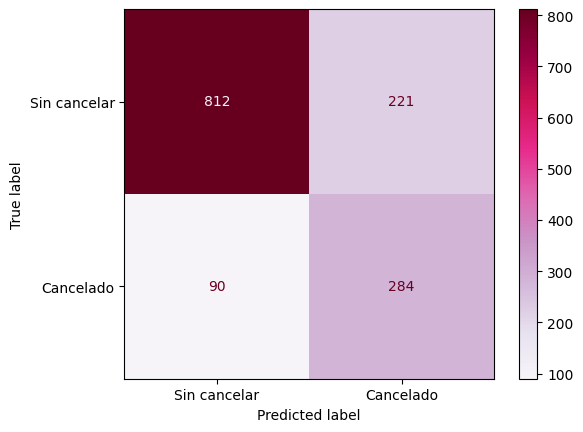

In [201]:
#Matris de confusión
matriz_rf = confusion_matrix(y_test, y_predic_rf_f)
ConfusionMatrixDisplay(matriz_rf,  display_labels=["Sin cancelar", "Cancelado"]).plot(cmap='PuRd')

In [202]:
intervalo_confianza(modelo_rf_final)

,metrica,promedio,desvio_std,intervalo_confianza_95
0,accuracy,0.770,0.005,"0.76, 0.781"
1,precision,0.552,0.026,"0.501, 0.603"
2,recall,0.718,0.017,"0.683, 0.752"
3,f1,0.624,0.017,"0.589, 0.658"


El modelo RandomForest, como se puede notar el punto fuerte del modelo es detectar los Verdaderos positivos, permitiendo conocer con mayor precision de antemano a quienes se puden marchar

#### **KNN**

In [203]:
y_predic_knn_f = modelo_knn_final.predict(X_test)
print(metricas(y_test, y_predic_knn_f))

Las metricas del modelo son:
Exactitud = 0.795
Precision = 0.622
Recall = 0.586
F1 Score = 0.603


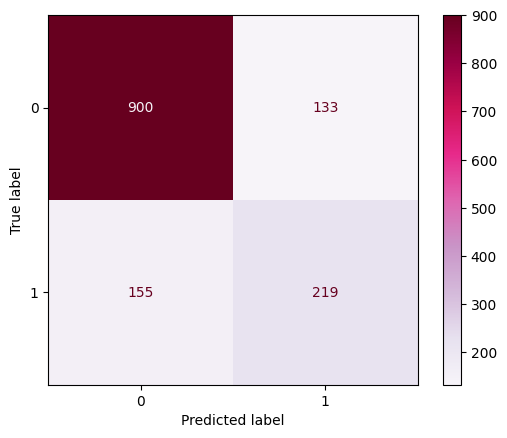

In [204]:
#Matris de confusión
matriz_knn = confusion_matrix(y_test, y_predic_knn_f)
ConfusionMatrixDisplay(matriz_knn).plot(cmap='PuRd')

In [205]:
intervalo_confianza(modelo_knn_final)

,metrica,promedio,desvio_std,intervalo_confianza_95
0,accuracy,0.781,0.010,"0.762, 0.801"
1,precision,0.658,0.041,"0.577, 0.74"
2,recall,0.373,0.029,"0.314, 0.432"
3,f1,0.475,0.021,"0.432, 0.517"


Caso contrario del KNN que tiene mayor precision al calcular los Negativos Positivos, pero tambien un mayor interbalo lo que puede ser muy perjudiciar, y al final lo que se quieres es asegurar que los que se van a ir se queden

## **📋 Interpretación y Conclusiones**

In [206]:
from sklearn.inspection import permutation_importance

Text(0.5, 1.0, 'Importancia de las Características - Random Forest')

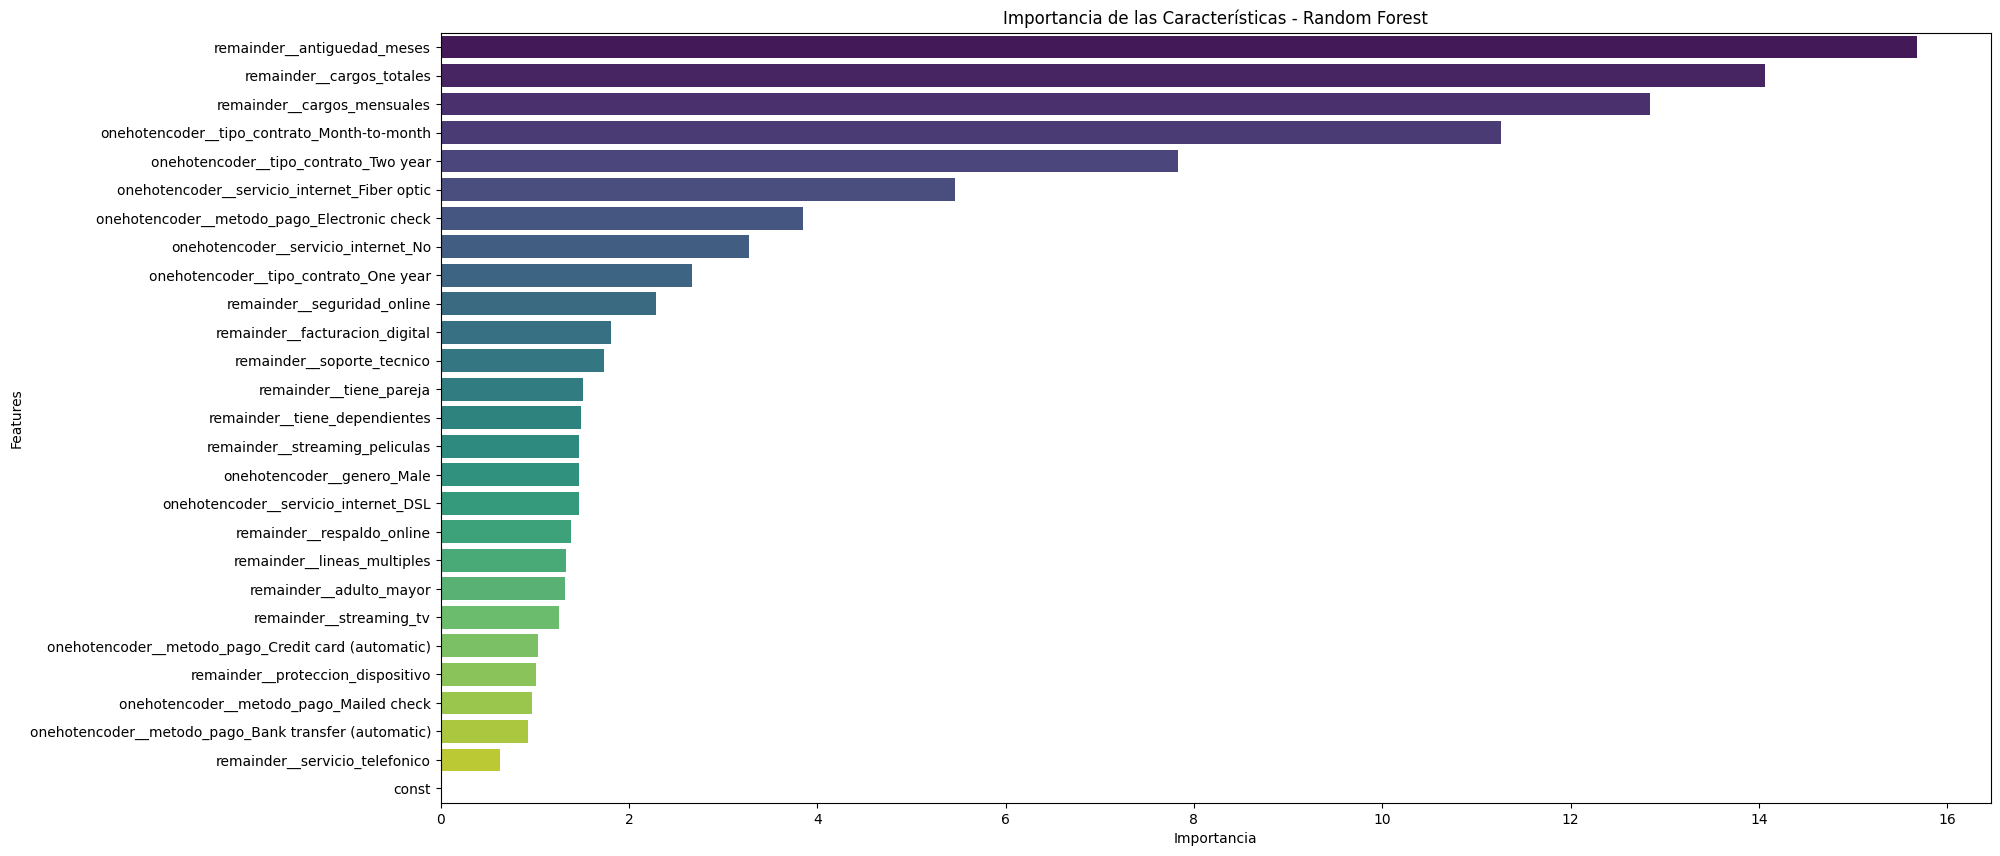

In [207]:
rf_feacture = modelo_rf_final.feature_importances_
feature_importance = pd.DataFrame({'Features':X_normalizado.columns,'Importancia':(rf_feacture*100).round(2)}).sort_values('Importancia', ascending=False)
plt.figure(figsize=(20, 10))
sns.barplot(data=feature_importance, x='Importancia', y='Features', palette='viridis')
plt.title('Importancia de las Características - Random Forest')

##### **KNN**

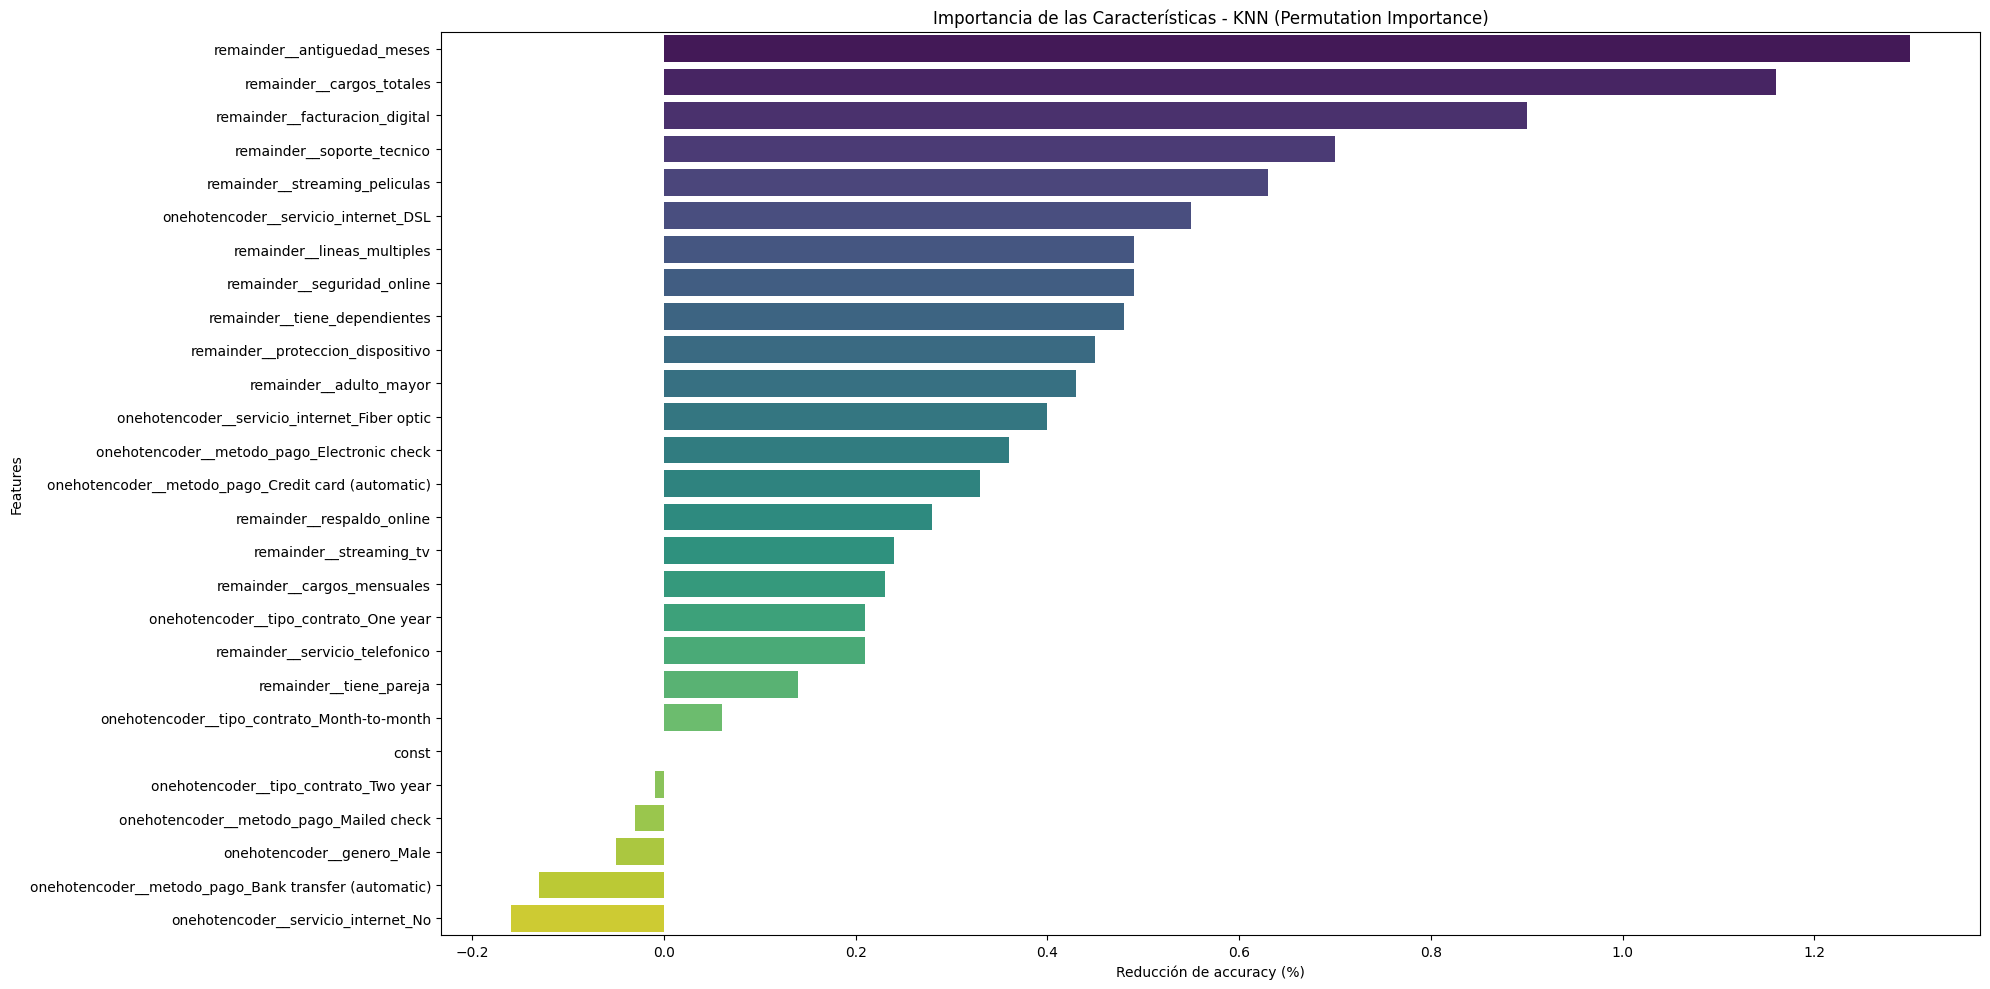

In [208]:

perm_imp = permutation_importance(modelo_knn_final, X_test, y_test, n_repeats=10, random_state=13, n_jobs=-1)

feature_importance_knn = pd.DataFrame({
    'Features': X_normalizado.columns,
    'Importancia': (perm_imp.importances_mean * 100).round(2)
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(20, 10))
sns.barplot(data=feature_importance_knn, x='Importancia', y='Features', palette='viridis')
plt.title('Importancia de las Características - KNN (Permutation Importance)')
plt.xlabel('Reducción de accuracy (%)')
plt.tight_layout()
plt.show()


Es facil no se comparte principalmente en las esferas mas amplias haciendose notar la antiguedad del cliente es le factor mas influyente

### **Conclusion**

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

A lo largo del trabajo se analizaron dos enfoques de clasificación para predecir cancelación: **RandomForest** y **KNN**. Ambos modelos superan el baseline y alcanzan un desempeño sólido (exactitud general superior al 75%), por lo que son útiles para apoyar decisiones de negocio. Sin embargo, al evaluar el problema desde una perspectiva de retención, no basta con la exactitud: es clave identificar correctamente a quienes tienen mayor riesgo de irse.

En línea con los mapas de calor y el análisis dirigido, los factores con mayor influencia fueron:

- **Tipo de contrato mes a mes**: aparece como uno de los impulsores más fuertes de cancelación.
- **Antigüedad del cliente**: muestra relación inversa con churn; mientras más tiempo lleva el cliente en el servicio, menor es la probabilidad de cancelar.
- **Servicios de valor agregado** (como seguridad online y soporte técnico): se asocian con menor cancelación.
- **Variables de precio y método de pago**: también muestran patrones relevantes en los gráficos comparativos.

En la comparación entre modelos, KNN ofrece buena precisión global, pero **RandomForest** destaca mejor en el objetivo principal del negocio: detectar clientes que efectivamente pueden cancelar (mejor equilibrio para escenarios donde es más costoso perder un cliente que contactar preventivamente a uno que finalmente no se iría). Aunque esto pueda implicar más falsos positivos, el costo operativo suele ser menor frente al costo de churn no prevenido.

Con base en estos resultados, la estrategia recomendada es operativizar el modelo de riesgo de forma periódica (semanal o mensual) y segmentar acciones por nivel de probabilidad de cancelación:

1. **Riesgo alto**: campañas inmediatas de retención con ofertas personalizadas, beneficios temporales y contacto proactivo.
2. **Riesgo medio**: incentivos para migrar de contrato mensual a esquemas de mayor permanencia (semestral/anual) y reforzar adopción de soporte/seguridad.
3. **Riesgo bajo**: acciones de fidelización ligera (cross-sell, programas de beneficios, seguimiento de satisfacción).

Como siguiente paso analítico, conviene definir un **umbral de decisión** orientado al negocio (no solo al 0.5 por defecto), monitorear métricas por cohorte y medir el impacto real de las campañas (reducción de churn, costo por cliente retenido y retorno de la intervención). De esta manera, el modelo no solo predice, sino que se convierte en una herramienta de retención continua y medible.